# Demonstration: Generalized VB Driver with Orbital Classification

This notebook demonstrates the new generalization step in the VeloxChem VB driver. The driver now uses the OrbitalAnalyzer to automatically classify orbitals (sigma, pi, etc.) for any molecule and basis, laying the foundation for robust, flexible VB calculations.

## Example: Sigma/Pi Classification for a Small Molecule

In [1]:
import veloxchem as vlx
import veloxchem.vbdriver as vbdriver_module
import veloxchem.orbitalanalyzerdriver as analyzer_module
from veloxchem.vbdriver import VbDriver, VbComputeOptions

print("VB driver module:", vbdriver_module.__file__)
print("OrbitalAnalyzer module:", analyzer_module.__file__)

# Define a small closed-shell molecule for the shared analyzer path.
mol = vlx.Molecule.read_xyz_string('''3
water
O 0.000 0.000 0.000
H 0.758 0.000 0.584
H -0.758 0.000 0.584
''')
basis = vlx.MolecularBasis.read(mol, 'sto-3g')

vb = VbDriver()
results = vb.compute(mol, basis)

# Show all analyzer-derived orbitals exposed through VB diagnostics.
print('Orbital analysis source:', results['diagnostics'].get('orbital_analysis_source'))
print('Orbital labels:', results['diagnostics'].get('orbital_labels', []))
print('Orbital types:', results['diagnostics'].get('orbital_types', []))
print('Diagnostics:', results['diagnostics']['message'])

VB driver module: /home/mathieu-linares/miniconda3/envs/vlxsrc/lib/python3.13/site-packages/veloxchem/vbdriver.py
OrbitalAnalyzer module: /home/mathieu-linares/miniconda3/envs/vlxsrc/lib/python3.13/site-packages/veloxchem/orbitalanalyzerdriver.py
                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock                                         
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
               

## Shared NBO/VB analyzer consistency check

This checks that `VbDriver` and `NboDriver` see the same candidate labels from the shared `OrbitalAnalyzer` payload. Run this after compiling/installing the local source into the `vlxsrc` environment.

In [25]:
from veloxchem.orbitalanalyzerdriver import OrbitalAnalyzer, OrbitalAnalyzerOptions

scf = vlx.ScfRestrictedDriver()
scf.compute(mol, basis)
analysis = OrbitalAnalyzer(
    mol,
    basis,
    mol_orbs=scf.mol_orbs,
    options=OrbitalAnalyzerOptions(include_mo_analysis=False),
).run()

analyzer_labels = [
    f"{c['type']}_{c.get('subtype', '')}_{c['index']}".replace("__", "_")
    for c in analysis.orbital_candidates
]
vb_labels = results["diagnostics"].get("orbital_labels", [])

nbo = vlx.NboDriver()
nbo.verbose = False
nbo_results = nbo.compute(mol, basis, scf.mol_orbs)
nbo_analysis_labels = [
    f"{c['type']}_{c.get('subtype', '')}_{c['index']}".replace("__", "_")
    for c in nbo_results["orbital_analysis"].orbital_candidates
]

print("Analyzer labels:", analyzer_labels)
print("VB labels:      ", vb_labels)
print("NBO labels:     ", nbo_analysis_labels)
assert vb_labels == analyzer_labels
assert nbo_analysis_labels == analyzer_labels

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock                                         
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

# Test of VBDriver: Minimal H2 VB-CI

This notebook demonstrates and tests the minimal valence bond configuration interaction (VB-CI) implementation for H$_2$ in VeloxChem.

In [2]:
# Import required libraries
import numpy as np
from veloxchem.vbdriver import VbDriver, VbComputeOptions, VbOrbital, VbStructure

In [27]:
import sys
import os

print("Python executable:", sys.executable)
print("sys.path:")
for p in sys.path:
    print("  ", p)
print("Conda prefix:", os.environ.get("CONDA_PREFIX", "not set"))

try:
    import veloxchem.veloxchemlib as veloxchemlib
    print("veloxchemlib location:", veloxchemlib.__file__)
except ImportError:
    print("veloxchemlib not found in this environment!")

Python executable: /home/mathieu-linares/miniconda3/envs/vlxsrc/bin/python
sys.path:
   /home/mathieu-linares/miniconda3/envs/vlxsrc/lib/python313.zip
   /home/mathieu-linares/miniconda3/envs/vlxsrc/lib/python3.13
   /home/mathieu-linares/miniconda3/envs/vlxsrc/lib/python3.13/lib-dynload
   
   /home/mathieu-linares/miniconda3/envs/vlxsrc/lib/python3.13/site-packages
Conda prefix: /home/mathieu-linares/miniconda3/envs/vlxsrc
veloxchemlib location: /home/mathieu-linares/miniconda3/envs/vlxsrc/lib/python3.13/site-packages/veloxchem/veloxchemlib.cpython-313-x86_64-linux-gnu.so


In [28]:
# Initialize VeloxChem Molecule Object for H2
import veloxchem as vlx

# Define H2 geometry (in Angstrom)
h2_xyz = """
2
H2 molecule
H 0.0 0.0 0.0
H 0.74 0.0 0.0
"""

molecule = vlx.Molecule.read_xyz_string(h2_xyz)
# Use a larger basis set for meaningful VB structure algebra
basis = vlx.MolecularBasis.read(molecule, '6-31g')


## Phase 4 preview: one active H2 bond from `OrbitalAnalyzer`

This cell exercises the new active-space bridge. No explicit VB structures or active orbitals are supplied: `VbDriver` asks `OrbitalAnalyzer` for the H-H bond candidate, builds one active bond, generates covalent/ionic structures, and solves the resulting two-orbital VB-CI problem.

In [29]:
# Build the first general VB active space directly from analyzer candidates.
active_options = VbComputeOptions(mode='vbci', optimize_orbitals=False)
vb = VbDriver()
active_results = vb.compute(molecule, basis, options=active_options)
active_space = active_results['active_space']

print('Active-space model:', active_results['diagnostics']['active_space_model'])
print('Active bond:', active_space.active_bond)
print('Active candidate:', active_space.active_candidate_label)
print('Active orbitals:', active_results['diagnostics']['active_orbital_labels'])
print('Generated structures:', active_results['diagnostics']['generated_structure_labels'])
print('Energy:', active_results['energy'])
print('Weights:', active_results['weights'])

assert active_space.active_bond == (0, 1)
assert active_results['diagnostics']['generated_structure_labels'] == [
    'covalent',
    'ionic_A_minus_B_plus',
    'ionic_A_plus_B_minus',
]

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock                                         
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

In [30]:
# Set Up VBDriver Calculation: define three VB structures (orbitals will be constructed by the driver)
# Covalent: one electron on each atom
covalent = VbStructure(label='covalent', occupation=((1, 1),), spin='singlet', charge_pattern={0: 0, 1: 0})
# Ionic 1: both electrons on atom 1
ionic1 = VbStructure(label='ionic1', occupation=((2, 0),), spin='singlet', charge_pattern={0: -1, 1: +1})
# Ionic 2: both electrons on atom 2
ionic2 = VbStructure(label='ionic2', occupation=((0, 2),), spin='singlet', charge_pattern={0: +1, 1: -1})

structures = [covalent, ionic1, ionic2]
options = VbComputeOptions(mode='vbci', optimize_orbitals=False)
# Do not define orbitals here; let the driver construct them


In [31]:
# Run VBDriver Calculation
vb = VbDriver()
results = vb.compute(molecule, basis, structures, options=options)


In [32]:
# Display Calculation Results
from pprint import pprint
print("VBDriver minimal H2 VB-CI result:")
pprint(results)

VBDriver minimal H2 VB-CI result:
{'Hamiltonian': array([[-4.65979328, -3.19283875, -3.19283875],
       [-3.19283875, -2.27413803, -1.92875987],
       [-3.19283875, -1.92875987, -2.27413803]]),
 'diagnostics': {'available_weight_schemes': ['Chirgwin-Coulson', 'Lowdin'],
                 'message': 'Two-electron VB-CI result from spin-adapted '
                            'singlet structures.',
                 'overlap_condition': 32.565543598849835,
                 'overlap_eigenvalues': [0.24455369365454474,
                                         1.3955756801199968,
                                         7.9640239729668725],
                 'retained_overlap_rank': 3,
                 'weight_scheme': 'Chirgwin-Coulson'},
 'energy': -1.141434374256794,
 'lowdin_weights': array([0.60891137, 0.19554432, 0.19554432]),
 'orbitals': [array([0.70710678, 0.70710678, 0.        , 0.        ]),
              array([0.        , 0.        , 0.70710678, 0.70710678])],
 'overlap': array([[

In [33]:
# Independent manual check of the spin-adapted two-orbital VB matrices
import numpy as np
import veloxchem as vlx
from veloxchem import FockDriver

# AO integrals from the supported VeloxChem Python API
T_ao = vlx.KineticEnergyDriver().compute(molecule, basis).to_numpy()
V_ao = vlx.NuclearPotentialDriver().compute(molecule, basis).to_numpy()
H_ao = T_ao - V_ao
S_ao = vlx.OverlapDriver().compute(molecule, basis).to_numpy()
eri_ao = FockDriver().compute_eri(molecule, basis, eri_thresh=1.0e-12)
e_nuc = molecule.effective_nuclear_repulsion_energy(basis)

assert np.max(np.abs(eri_ao)) > 1.0e-14, "AO ERIs are zero; rebuild/check the ERI path before interpreting VB energies."

# Use the same atom-centered orbitals and structures as VBDriver.
C = np.column_stack([results["orbitals"][0], results["orbitals"][1]])
S, H = vb._build_two_orbital_singlet_matrices(structures, C, H_ao, S_ao, eri_ao, e_nuc)
E_fci, C_fci, W_fci, kept, W_lowdin = vb._solve_generalized_vb(H, S, return_lowdin=True)

print("Manual spin-adapted VB energy:", E_fci)
print("Manual spin-adapted coefficients:", C_fci)
print("Manual Chirgwin-Coulson weights:", W_fci)
print("Manual Lowdin weights:", W_lowdin)
print("Retained overlap rank:", len(kept))
print("Overlap eigenvalues:", np.linalg.eigvalsh(S))
print("Hamiltonian matrix:\n", H)

assert np.allclose(E_fci, results["energy"])
assert np.allclose(W_fci, results["weights"])
assert np.allclose(W_lowdin, results["lowdin_weights"])
assert len(kept) == 3

Manual spin-adapted VB energy: -1.141434374256794
Manual spin-adapted coefficients: [0.40572828 0.06532426 0.06532426]
Manual Chirgwin-Coulson weights: [0.82030059 0.0898497  0.0898497 ]
Manual Lowdin weights: [0.60891137 0.19554432 0.19554432]
Retained overlap rank: 3
Overlap eigenvalues: [0.24455369 1.39557568 7.96402397]
Hamiltonian matrix:
 [[-4.65979328 -3.19283875 -3.19283875]
 [-3.19283875 -2.27413803 -1.92875987]
 [-3.19283875 -1.92875987 -2.27413803]]


Comparison of VBDriver and manual spin-adapted matrix check:
VBDriver energy: -1.14143437
Manual energy:   -1.14143437

VBDriver structure coefficients: [0.40572828 0.06532426 0.06532426]
VBDriver Chirgwin-Coulson weights: [0.82030059 0.0898497  0.0898497 ]
VBDriver Lowdin weights: [0.60891137 0.19554432 0.19554432]
Manual coefficients: [0.40572828 0.06532426 0.06532426]


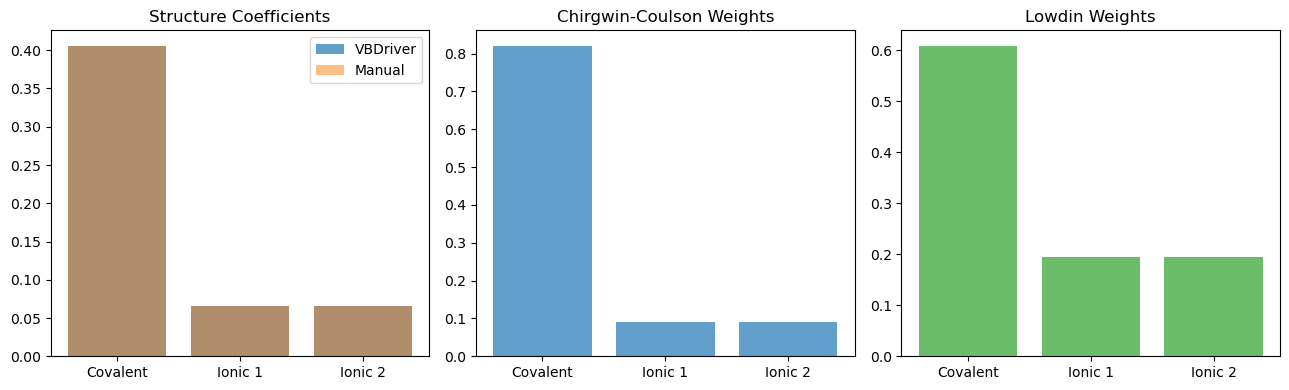

In [34]:
# Automated comparison of VBDriver and the manual matrix check
import numpy as np
import matplotlib.pyplot as plt

# Extract energies
vb_energy = results["energy"]
manual_energy = E_fci

# Extract structure coefficients and weights
vb_coeffs = results["structure_coefficients"]
vb_weights = results["weights"]
vb_lowdin_weights = results["lowdin_weights"]
manual_coeffs = C_fci

# Print summary
print("Comparison of VBDriver and manual spin-adapted matrix check:")
print(f"VBDriver energy: {vb_energy:.8f}")
print(f"Manual energy:   {manual_energy:.8f}")
print("\nVBDriver structure coefficients:", vb_coeffs)
print("VBDriver Chirgwin-Coulson weights:", vb_weights)
print("VBDriver Lowdin weights:", vb_lowdin_weights)
print("Manual coefficients:", manual_coeffs)

# Bar plot of coefficients/weights
labels = ["Covalent", "Ionic 1", "Ionic 2"]
fig, axs = plt.subplots(1, 3, figsize=(13, 4))
axs[0].bar(labels, vb_coeffs, color="tab:blue", alpha=0.7, label="VBDriver")
axs[0].bar(labels, manual_coeffs, color="tab:orange", alpha=0.5, label="Manual")
axs[0].set_title("Structure Coefficients")
axs[0].legend()
axs[1].bar(labels, vb_weights, color="tab:blue", alpha=0.7)
axs[1].set_title("Chirgwin-Coulson Weights")
axs[2].bar(labels, vb_lowdin_weights, color="tab:green", alpha=0.7)
axs[2].set_title("Lowdin Weights")
plt.tight_layout()
plt.show()

In [35]:
# Diagnostic only: H2 VB-SCF one-angle orbital optimization via driver
# The fixed-orbital VB-CI cells above are the validated baseline. This cell is
# retained to inspect the prototype orbital optimizer before using it in scans.
options_vbscf = VbComputeOptions(mode='vbscf', optimize_orbitals=True)
vb = VbDriver()
results_vbscf = vb.compute(molecule, basis, structures, options=options_vbscf)

from pprint import pprint
print("H2 VB-SCF diagnostic result:")
pprint(results_vbscf)
if 'diagnostics' in results_vbscf:
    print("\nDiagnostics:")
    for k, v in results_vbscf['diagnostics'].items():
        print(f"{k}: {v}")

H2 VB-SCF diagnostic result:
{'Hamiltonian': array([[-1.62225418,  1.20409601,  1.01965189],
       [ 1.20409601, -0.9508303 , -0.6581866 ],
       [ 1.01965189, -0.6581866 , -0.64517452]]),
 'diagnostics': {'available_weight_schemes': ['Chirgwin-Coulson', 'Lowdin'],
                 'message': 'H2 VB-SCF result (spin-adapted two-electron '
                            'algebra)',
                 'optimizer':  message: Solution found.
 success: True
  status: 0
     fun: -1.1414343742567952
       x: 1.4151204228654535
     nit: 37
    nfev: 37,
                 'overlap_condition': 28.40820468106451,
                 'overlap_eigenvalues': [0.09983010357311545,
                                         0.5320879403949788,
                                         2.8359940156369268],
                 'retained_overlap_rank': 3,
                 'theta_opt': np.float64(1.4151204228654535),
                 'weight_scheme': 'Chirgwin-Coulson'},
 'energy': -1.1414343742567952,
 'lowdin_wei

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock                                         
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

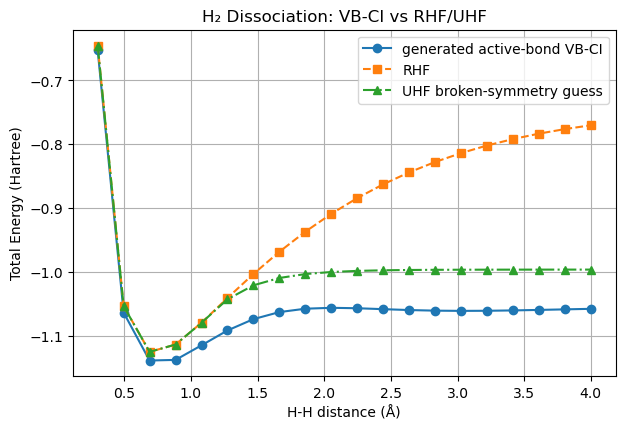

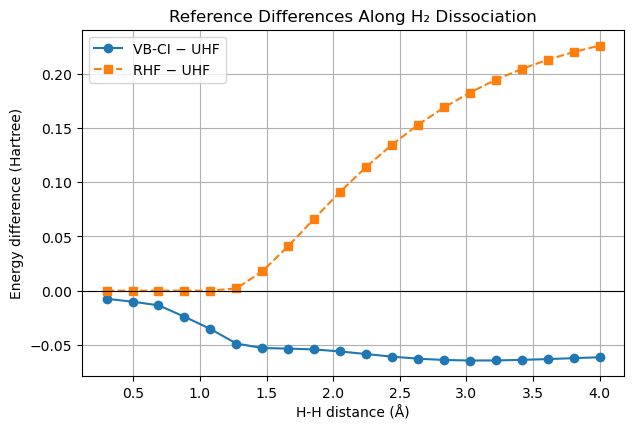

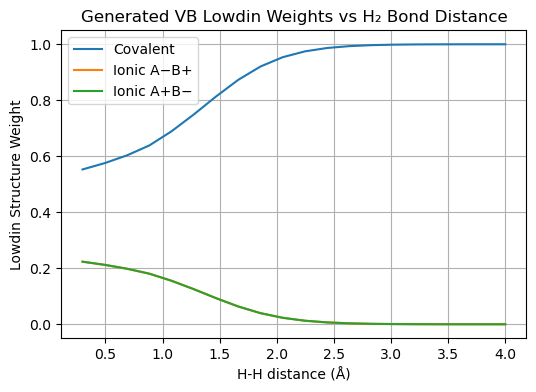

Active candidates along scan: ['BD_sigma_1', 'BD_sigma_1', 'BD_sigma_1', 'BD_sigma_0', 'BD_sigma_0', 'BD_sigma_0', 'BD_sigma_0', 'BD_sigma_0', 'BD_sigma_0', 'BD_sigma_0', 'BD_sigma_0', 'BD_sigma_0', 'BD_sigma_0', 'BD_sigma_0', 'BD_sigma_0', 'BD_sigma_0', 'BD_sigma_0', 'BD_sigma_0', 'BD_sigma_0', 'BD_sigma_0']
Chirgwin-Coulson weights at shortest distance: [0.55290912 0.22354544 0.22354544]
Lowdin weights at shortest distance: [0.55290912 0.22354544 0.22354544]
Energy comparison at largest distance:
  VB-CI: -1.057996016006
  RHF:   -0.770202601600
  UHF:   -0.996485078491
Diagnostics at largest distance:
message: Generated VB result from OrbitalAnalyzer active-space candidates.
overlap_condition: 1.013042423706582
overlap_eigenvalues: [0.9935314652866941, 0.9999895055452594, 1.0064895236227847]
retained_overlap_rank: 3
weight_scheme: Chirgwin-Coulson
available_weight_schemes: ['Chirgwin-Coulson', 'Lowdin']
frozen_hf_embedding: True
frozen_electron_count: -1.6653345369377348e-16
active_

In [36]:
# H2 dissociation curve with generated one-active-bond VB-CI
import numpy as np
import matplotlib.pyplot as plt

# Define bond distances (in Angstrom)
distances = np.linspace(0.3, 4.0, 20)

# No explicit structures are supplied here. The driver builds the active H-H
# bond and covalent/ionic structures from OrbitalAnalyzer candidates at each R.
# Keep this first dissociation scan as VB-CI over atom-centered active orbitals;
# orbital optimization is a separate diagnostic cell until its constraints are improved.
options_scan = VbComputeOptions(mode='vbci', optimize_orbitals=False)
vb = VbDriver()

def run_hf_reference(molecule, basis, unrestricted=False):
    """Run a compact HF reference calculation and return the total SCF energy."""
    scf_drv = vlx.ScfUnrestrictedDriver() if unrestricted else vlx.ScfRestrictedDriver()
    scf_drv.ostream.mute()
    scf_drv.xcfun = 'hf'
    if unrestricted:
        # Broken-symmetry singlet guess: alpha density starts on atom 1 and beta on atom 2.
        # At short distances UHF may collapse back to RHF; at long distances it should
        # recover the correct separated-atom limit much better than RHF.
        scf_drv.guess_unpaired_electrons = '1(1),2(-1)'
    scf_drv.compute(molecule, basis)
    return scf_drv.get_scf_energy()

energies = []
rhf_energies = []
uhf_energies = []
cc_weights = []
lowdin_weights = []
diagnostics = []
active_labels = []

for R in distances:
    h2_xyz = f"""2
H2 molecule
H 0.0 0.0 0.0
H {R:.8f} 0.0 0.0
"""
    molecule_R = vlx.Molecule.read_xyz_string(h2_xyz)
    basis_R = vlx.MolecularBasis.read(molecule_R, '6-31g')

    results_R = vb.compute(molecule_R, basis_R, options=options_scan)
    energies.append(results_R['energy'])
    cc_weights.append(results_R['weights'])
    lowdin_weights.append(results_R['lowdin_weights'])
    diagnostics.append(results_R.get('diagnostics', {}))
    active_labels.append(results_R['active_space'].active_candidate_label)

    rhf_energies.append(run_hf_reference(molecule_R, basis_R, unrestricted=False))
    uhf_energies.append(run_hf_reference(molecule_R, basis_R, unrestricted=True))

energies = np.array(energies)
rhf_energies = np.array(rhf_energies)
uhf_energies = np.array(uhf_energies)
cc_weights = np.array(cc_weights)
lowdin_weights = np.array(lowdin_weights)
weights = cc_weights  # backward-compatible name for the compact summary cell

assert np.all(np.isfinite(energies))
assert np.all(np.isfinite(rhf_energies))
assert np.all(np.isfinite(uhf_energies))
assert all(d.get('retained_overlap_rank') == 3 for d in diagnostics)
assert np.allclose(np.sum(cc_weights, axis=1), 1.0)
assert np.allclose(np.sum(lowdin_weights, axis=1), 1.0)

# Plot total energy vs bond distance, including RHF/UHF references.
plt.figure(figsize=(7, 4.5))
plt.plot(distances, energies, marker='o', label='generated active-bond VB-CI')
plt.plot(distances, rhf_energies, marker='s', linestyle='--', label='RHF')
plt.plot(distances, uhf_energies, marker='^', linestyle='-.', label='UHF broken-symmetry guess')
plt.xlabel('H-H distance (Å)')
plt.ylabel('Total Energy (Hartree)')
plt.title('H₂ Dissociation: VB-CI vs RHF/UHF')
plt.grid(True)
plt.legend()
plt.show()

# Plot relative errors against UHF to make the dissociation-limit behavior visible.
plt.figure(figsize=(7, 4.5))
plt.plot(distances, energies - uhf_energies, marker='o', label='VB-CI − UHF')
plt.plot(distances, rhf_energies - uhf_energies, marker='s', linestyle='--', label='RHF − UHF')
plt.axhline(0.0, color='black', linewidth=0.8)
plt.xlabel('H-H distance (Å)')
plt.ylabel('Energy difference (Hartree)')
plt.title('Reference Differences Along H₂ Dissociation')
plt.grid(True)
plt.legend()
plt.show()

# Plot Lowdin weights for bounded visual interpretation.
plt.figure(figsize=(6, 4))
plt.plot(distances, lowdin_weights[:, 0], label='Covalent')
if lowdin_weights.shape[1] > 1:
    plt.plot(distances, lowdin_weights[:, 1], label='Ionic A−B+')
if lowdin_weights.shape[1] > 2:
    plt.plot(distances, lowdin_weights[:, 2], label='Ionic A+B−')
plt.xlabel('H-H distance (Å)')
plt.ylabel('Lowdin Structure Weight')
plt.title('Generated VB Lowdin Weights vs H₂ Bond Distance')
plt.grid(True)
plt.legend()
plt.show()

print('Active candidates along scan:', active_labels)
print('Chirgwin-Coulson weights at shortest distance:', cc_weights[0])
print('Lowdin weights at shortest distance:', lowdin_weights[0])
print('Energy comparison at largest distance:')
print(f"  VB-CI: {energies[-1]: .12f}")
print(f"  RHF:   {rhf_energies[-1]: .12f}")
print(f"  UHF:   {uhf_energies[-1]: .12f}")
print('Diagnostics at largest distance:')
for k, v in diagnostics[-1].items():
    print(f"{k}: {v}")

In [37]:
# Compact analysis summary for VB notebook results
import numpy as np

print('--- Active-space H2 one-geometry summary ---')
if 'active_results' in globals():
    print('energy:', active_results.get('energy'))
    print('Chirgwin-Coulson weights:', np.asarray(active_results.get('weights')))
    print('Lowdin weights:', np.asarray(active_results.get('lowdin_weights')))
    print('coefficients:', np.asarray(active_results.get('structure_coefficients')))
    print('overlap condition:', active_results.get('diagnostics', {}).get('overlap_condition'))
    print('overlap eigenvalues:', active_results.get('diagnostics', {}).get('overlap_eigenvalues'))
    print('active candidate:', active_results.get('diagnostics', {}).get('active_candidate_label'))
    print('structures:', active_results.get('diagnostics', {}).get('generated_structure_labels'))

print('\n--- Explicit H2 VB-CI summary ---')
if 'results' in globals():
    print('energy:', results.get('energy'))
    print('Chirgwin-Coulson weights:', np.asarray(results.get('weights')))
    print('Lowdin weights:', np.asarray(results.get('lowdin_weights')))
    print('coefficients:', np.asarray(results.get('structure_coefficients')))
    print('overlap condition:', results.get('diagnostics', {}).get('overlap_condition'))

print('\n--- Manual spin-adapted matrix summary ---')
if 'E_fci' in globals():
    print('E_manual:', E_fci)
    print('C_manual:', C_fci)
    if 'W_fci' in globals():
        print('W_manual_CC:', W_fci)
    if 'W_lowdin' in globals():
        print('W_manual_Lowdin:', W_lowdin)

print('\n--- VB-SCF one-geometry diagnostic summary ---')
if 'results_vbscf' in globals():
    print('energy:', results_vbscf.get('energy'))
    print('Chirgwin-Coulson weights:', np.asarray(results_vbscf.get('weights')))
    print('Lowdin weights:', np.asarray(results_vbscf.get('lowdin_weights')))
    print('coefficients:', np.asarray(results_vbscf.get('structure_coefficients')))
    print('theta:', results_vbscf.get('diagnostics', {}).get('theta_opt'))
    print('overlap condition:', results_vbscf.get('diagnostics', {}).get('overlap_condition'))

print('\n--- VB-CI/RHF/UHF dissociation summary ---')
if 'distances' in globals() and 'energies' in globals() and 'weights' in globals():
    have_hf_refs = 'rhf_energies' in globals() and 'uhf_energies' in globals()
    if have_hf_refs:
        print('distance VB-CI RHF UHF VB-UHF RHF-UHF CC_cov CC_ion1 CC_ion2 Lowdin_cov Lowdin_ion1 Lowdin_ion2')
    else:
        print('distance VB-CI CC_cov CC_ion1 CC_ion2 Lowdin_cov Lowdin_ion1 Lowdin_ion2')
    lowdin_table = lowdin_weights if 'lowdin_weights' in globals() else weights
    for idx in range(len(distances)):
        cc_row = np.asarray(weights[idx])
        lowdin_row = np.asarray(lowdin_table[idx])
        cc_padded = np.pad(cc_row, (0, max(0, 3 - cc_row.size)), constant_values=np.nan)
        lowdin_padded = np.pad(lowdin_row, (0, max(0, 3 - lowdin_row.size)), constant_values=np.nan)
        if have_hf_refs:
            print(
                f'{distances[idx]:.3f} {energies[idx]: .8e} {rhf_energies[idx]: .8e} {uhf_energies[idx]: .8e} '
                f'{energies[idx] - uhf_energies[idx]: .3e} {rhf_energies[idx] - uhf_energies[idx]: .3e} '
                f'{cc_padded[0]: .6f} {cc_padded[1]: .6f} {cc_padded[2]: .6f} '
                f'{lowdin_padded[0]: .6f} {lowdin_padded[1]: .6f} {lowdin_padded[2]: .6f}'
            )
        else:
            print(
                f'{distances[idx]:.3f} {energies[idx]: .8e} '
                f'{cc_padded[0]: .6f} {cc_padded[1]: .6f} {cc_padded[2]: .6f} '
                f'{lowdin_padded[0]: .6f} {lowdin_padded[1]: .6f} {lowdin_padded[2]: .6f}'
            )
    print('finite VB-CI energies:', bool(np.all(np.isfinite(energies))))
    if have_hf_refs:
        print('finite RHF energies:', bool(np.all(np.isfinite(rhf_energies))))
        print('finite UHF energies:', bool(np.all(np.isfinite(uhf_energies))))
    print('VB-CI energy min/max:', float(np.nanmin(energies)), float(np.nanmax(energies)))
    if have_hf_refs:
        print('RHF energy min/max:', float(np.nanmin(rhf_energies)), float(np.nanmax(rhf_energies)))
        print('UHF energy min/max:', float(np.nanmin(uhf_energies)), float(np.nanmax(uhf_energies)))
    if 'diagnostics' in globals() and diagnostics:
        print('last diagnostics:', diagnostics[-1])

--- Active-space H2 one-geometry summary ---
energy: -1.1412653929587475
Chirgwin-Coulson weights: [0.61110607 0.19444696 0.19444696]
Lowdin weights: [0.61110607 0.19444696 0.19444696]
coefficients: [-0.78173274 -0.44096141 -0.44096141]
overlap condition: 1.0000000000000002
overlap eigenvalues: [0.999999999999999, 0.9999999999999998, 1.0]
active candidate: BD_sigma_1
structures: ['covalent', 'ionic_A_minus_B_plus', 'ionic_A_plus_B_minus']

--- Explicit H2 VB-CI summary ---
energy: -1.141434374256794
Chirgwin-Coulson weights: [0.82030059 0.0898497  0.0898497 ]
Lowdin weights: [0.60891137 0.19554432 0.19554432]
coefficients: [0.40572828 0.06532426 0.06532426]
overlap condition: 32.565543598849835

--- Manual spin-adapted matrix summary ---
E_manual: -1.141434374256794
C_manual: [0.40572828 0.06532426 0.06532426]
W_manual_CC: [0.82030059 0.0898497  0.0898497 ]
W_manual_Lowdin: [0.60891137 0.19554432 0.19554432]

--- VB-SCF one-geometry diagnostic summary ---
energy: -1.1414343742567952
Ch

## Ethylene sigma/pi separation preview

This cell is the next generalization checkpoint. It does not solve an ethylene VB wavefunction yet. Instead, it verifies that `VbDriver` exposes the `OrbitalAnalyzer` bond manifold in a VB-facing form: C=C sigma candidates, C=C pi candidates, and suggested active candidates. After recompiling, the pi candidate label reported here is the intended entry point for the next one-active-π-bond VB model.

In [38]:
# Ethylene C=C sigma/pi separation through VbDriver diagnostics
import veloxchem as vlx
from veloxchem.vbdriver import VbDriver, VbComputeOptions

ethylene_xyz = """6
ethylene
C -0.6695  0.0000  0.0000
C  0.6695  0.0000  0.0000
H -1.2321  0.9289  0.0000
H -1.2321 -0.9289  0.0000
H  1.2321  0.9289  0.0000
H  1.2321 -0.9289  0.0000
"""

ethylene = vlx.Molecule.read_xyz_string(ethylene_xyz)
ethylene_basis = vlx.MolecularBasis.read(ethylene, 'sto-3g')

# Keep automatic active-space generation off here: the purpose is to inspect
# analyzer-derived bond manifolds before turning the C=C pi candidate into a
# production VB active space.
vb = VbDriver()
ethylene_results = vb.compute(
    ethylene,
    ethylene_basis,
    options=VbComputeOptions(mode='vbci', optimize_orbitals=False, use_active_space=False),
)
ethylene_diag = ethylene_results['diagnostics']
partitions = ethylene_diag['candidate_partitions']

sigma_bonds = partitions['sigma_bonds']
pi_bonds = partitions['pi_bonds']
suggested = ethylene_diag['suggested_active_candidates']

print('Sigma bond candidates:')
for record in sigma_bonds:
    print(record)

print('\nPi bond candidates:')
for record in pi_bonds:
    print(record)

print('\nSuggested active candidates:')
for record in suggested:
    print(record)

# C atoms are atoms 0 and 1 in this geometry. The next VB target is the C=C pi
# candidate, while the C=C sigma bond and C-H sigma bonds remain inactive/frozen.
cc_pi = [record for record in pi_bonds if tuple(record['atoms']) == (0, 1)]
cc_sigma = [record for record in sigma_bonds if tuple(record['atoms']) == (0, 1)]

assert cc_pi, 'Expected a C=C pi bond candidate for ethylene.'
assert cc_sigma, 'Expected a C=C sigma bond candidate for ethylene.'

pi_label = cc_pi[0]['label']
sigma_label = cc_sigma[0]['label']
print('\nEthylene C=C sigma label:', sigma_label)
print('Ethylene C=C pi label:', pi_label)
print('Use this pi label for the next one-active-pi-bond VB prototype.')

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock                                         
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

## Ethylene one-active-π VB-CI with frozen HF sigma framework

This cell activates the analyzer-selected C=C π candidate and leaves the sigma framework at the RHF reference level. The active VB structures are the π covalent and ionic structures; the C=C sigma and C-H sigma candidates are reported as inactive/frozen diagnostics.

In [39]:
# Ethylene one-active-pi VB-CI. The pi_label variable is defined by the
# previous sigma/pi checkpoint cell; rerun that cell first after recompiling.
pi_options = VbComputeOptions(
    mode='vbci',
    optimize_orbitals=False,
    active_candidate_label=pi_label,
    active_candidate_subtype='pi',
    include_ionic=True,
    freeze_inactive_orbitals=True,
)
pi_vb_results = vb.compute(ethylene, ethylene_basis, options=pi_options)
pi_vb_diag = pi_vb_results['diagnostics']

print('Active-space model:', pi_vb_diag['active_space_model'])
print('Active candidate:', pi_vb_diag['active_candidate_label'], pi_vb_diag['active_candidate_subtype'])
print('Active bond:', pi_vb_diag['active_bond'])
print('Active orbitals:', pi_vb_diag['active_orbital_labels'])
print('Structures:', pi_vb_diag['generated_structure_labels'])
print('Inactive sigma framework:', pi_vb_diag['inactive_sigma_candidate_labels'])
print('Frozen HF embedding:', pi_vb_diag.get('frozen_hf_embedding', False))
print('Frozen electrons:', pi_vb_diag.get('frozen_electron_count'))
print('Active reference electrons:', pi_vb_diag.get('active_reference_electron_count'))
print('Frozen constant energy:', pi_vb_diag.get('frozen_constant_energy'))
print('VB-CI energy:', pi_vb_results['energy'])
print('Overlap eigenvalues:', pi_vb_diag['overlap_eigenvalues'])

for label, coeff, cc_weight, lowdin_weight in zip(
    pi_vb_diag['generated_structure_labels'],
    pi_vb_results['structure_coefficients'],
    pi_vb_results['weights'],
    pi_vb_results['lowdin_weights'],
):
    print(f'{label:22s} coeff={coeff: .8f} CC={cc_weight: .8f} Lowdin={lowdin_weight: .8f}')

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock                                         
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

## Allyl cation fixed-orbital multi-center π VB-CI

This validation cell is the first checkpoint for the general fixed-orbital π active-space engine. The allyl cation is treated as a 2e/3π singlet active space over the three carbon π centers, while the sigma/core framework is frozen at the RHF reference level. The generated structures include all covalent two-center π placements and one ionic placement on each active center.

In [40]:
# Allyl cation 2e/3pi fixed-orbital VB-CI validation.
# Carbon atoms 0, 1, and 2 define the conjugated pi active space.
allyl_cation_xyz = """8
allyl cation
C -1.3000  0.0000  0.0000
C  0.0000  0.0000  0.0000
C  1.3000  0.0000  0.0000
H -1.8500  0.9200  0.0000
H -1.8500 -0.9200  0.0000
H  0.0000  1.0800  0.0000
H  1.8500  0.9200  0.0000
H  1.8500 -0.9200  0.0000
"""

allyl_cation = vlx.Molecule.read_xyz_string(allyl_cation_xyz)
allyl_cation.set_charge(1)
allyl_cation.set_multiplicity(1)
allyl_basis = vlx.MolecularBasis.read(allyl_cation, 'sto-3g')

allyl_options = VbComputeOptions(
    mode='vbci',
    optimize_orbitals=False,
    active_pi_atoms=(0, 1, 2),
    active_electron_count=2,
    active_spin='singlet',
    include_ionic=True,
    freeze_inactive_orbitals=True,
)
allyl_vb_results = vb.compute(allyl_cation, allyl_basis, options=allyl_options)
allyl_vb_diag = allyl_vb_results['diagnostics']

print('Active-space model:', allyl_vb_diag['active_space_model'])
print('Active pi atoms:', allyl_vb_diag['active_pi_atoms'])
print('Component pi candidates:', allyl_vb_diag['component_pi_candidate_labels'])
print('Active orbitals:', allyl_vb_diag['active_orbital_labels'])
print('Structures:', allyl_vb_diag['generated_structure_labels'])
print('Frozen HF embedding:', allyl_vb_diag.get('frozen_hf_embedding', False))
print('Frozen electrons:', allyl_vb_diag.get('frozen_electron_count'))
print('Active reference electrons:', allyl_vb_diag.get('active_reference_electron_count'))
print('Frozen constant energy:', allyl_vb_diag.get('frozen_constant_energy'))
print('VB-CI energy:', allyl_vb_results['energy'])
print('Overlap eigenvalues:', allyl_vb_diag['overlap_eigenvalues'])

for label, coeff, cc_weight, lowdin_weight in zip(
    allyl_vb_diag['generated_structure_labels'],
    allyl_vb_results['structure_coefficients'],
    allyl_vb_results['weights'],
    allyl_vb_results['lowdin_weights'],
):
    print(f'{label:24s} coeff={coeff: .8f} CC={cc_weight: .8f} Lowdin={lowdin_weight: .8f}')

assert allyl_vb_diag['active_space_model'] == 'fixed-orbital-multicenter-pi'
assert allyl_vb_diag['active_pi_atoms'] == (0, 1, 2)
assert len(allyl_vb_diag['active_orbital_labels']) == 3
assert len(allyl_vb_diag['generated_structure_labels']) == 6
assert allyl_vb_diag['retained_overlap_rank'] == 6
assert np.isfinite(allyl_vb_results['energy'])
assert np.allclose(np.sum(allyl_vb_results['weights']), 1.0)
assert np.allclose(np.sum(allyl_vb_results['lowdin_weights']), 1.0)
assert np.isclose(allyl_vb_diag.get('active_reference_electron_count'), 2.0, atol=1.0e-8)
assert allyl_vb_diag.get('frozen_electron_count') > 0.0

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock                                         
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

## Fixed-orbital π validation ladder through benzene

This cell extends the multi-center π engine beyond allyl cation. It validates allyl radical, allyl anion, butadiene, and benzene using the same `active_pi_atoms` interface. The allyl cation remains the spin-adapted 2e benchmark above; larger/open-shell cases use the fixed-orbital determinant-CI fallback in the orthonormalized active π basis while retaining frozen-HF sigma/core embedding.

In [3]:
# Remaining fixed-orbital pi validation ladder: allyl radical, allyl anion,
# butadiene, and benzene. These cases exercise 3e/3pi, 4e/3pi, 4e/4pi,
# and 6e/6pi active spaces with frozen sigma/core embedding.
pi_validation_cases = [
    {
        'name': 'allyl_radical',
        'xyz': """8
allyl radical
C -1.3000  0.0000  0.0000
C  0.0000  0.0000  0.0000
C  1.3000  0.0000  0.0000
H -1.8500  0.9200  0.0000
H -1.8500 -0.9200  0.0000
H  0.0000  1.0800  0.0000
H  1.8500  0.9200  0.0000
H  1.8500 -0.9200  0.0000
""",
        'charge': 0,
        'multiplicity': 2,
        'active_pi_atoms': (0, 1, 2),
        'active_electron_count': 3,
        'active_spin': 'doublet',
        'expected_orbitals': 3,
        'expected_structures': 9,
    },
    {
        'name': 'allyl_anion',
        'xyz': """8
allyl anion
C -1.3000  0.0000  0.0000
C  0.0000  0.0000  0.0000
C  1.3000  0.0000  0.0000
H -1.8500  0.9200  0.0000
H -1.8500 -0.9200  0.0000
H  0.0000  1.0800  0.0000
H  1.8500  0.9200  0.0000
H  1.8500 -0.9200  0.0000
""",
        'charge': -1,
        'multiplicity': 1,
        'active_pi_atoms': (0, 1, 2),
        'active_electron_count': 4,
        'active_spin': 'singlet',
        'expected_orbitals': 3,
        'expected_structures': 9,
    },
    {
        'name': 'butadiene',
        'xyz': """10
butadiene
C -1.9950  0.0000  0.0000
C -0.6650  0.0000  0.0000
C  0.6650  0.0000  0.0000
C  1.9950  0.0000  0.0000
H -2.5500  0.9200  0.0000
H -2.5500 -0.9200  0.0000
H -0.6650  1.0800  0.0000
H  0.6650 -1.0800  0.0000
H  2.5500  0.9200  0.0000
H  2.5500 -0.9200  0.0000
""",
        'charge': 0,
        'multiplicity': 1,
        'active_pi_atoms': (0, 1, 2, 3),
        'active_electron_count': 4,
        'active_spin': 'singlet',
        'expected_orbitals': 4,
        'expected_structures': 36,
    },
    {
        'name': 'benzene',
        'xyz': """12
benzene
C  1.3970  0.0000  0.0000
C  0.6985  1.2099  0.0000
C -0.6985  1.2099  0.0000
C -1.3970  0.0000  0.0000
C -0.6985 -1.2099  0.0000
C  0.6985 -1.2099  0.0000
H  2.4810  0.0000  0.0000
H  1.2405  2.1487  0.0000
H -1.2405  2.1487  0.0000
H -2.4810  0.0000  0.0000
H -1.2405 -2.1487  0.0000
H  1.2405 -2.1487  0.0000
""",
        'charge': 0,
        'multiplicity': 1,
        'active_pi_atoms': (0, 1, 2, 3, 4, 5),
        'active_electron_count': 6,
        'active_spin': 'singlet',
        'expected_orbitals': 6,
        'expected_structures': 400,
    },
]

pi_ladder_results = {}
for case in pi_validation_cases:
    mol_case = vlx.Molecule.read_xyz_string(case['xyz'])
    mol_case.set_charge(case['charge'])
    mol_case.set_multiplicity(case['multiplicity'])
    basis_case = vlx.MolecularBasis.read(mol_case, 'sto-3g')
    options_case = VbComputeOptions(
        mode='vbci',
        optimize_orbitals=False,
        active_pi_atoms=case['active_pi_atoms'],
        active_electron_count=case['active_electron_count'],
        active_spin=case['active_spin'],
        include_ionic=True,
        freeze_inactive_orbitals=True,
    )
    result_case = vb.compute(mol_case, basis_case, options=options_case)
    diag_case = result_case['diagnostics']
    pi_ladder_results[case['name']] = result_case

    print(f"\n--- {case['name']} ---")
    print('Active-space model:', diag_case['active_space_model'])
    print('Active pi atoms:', diag_case['active_pi_atoms'])
    print('Active electron count:', diag_case['active_electron_count'])
    print('Active spin:', diag_case['active_spin'])
    print('n_alpha/n_beta:', diag_case.get('n_alpha'), diag_case.get('n_beta'))
    print('Active orbitals:', len(diag_case['active_orbital_labels']), diag_case['active_orbital_labels'])
    print('Structures/determinants:', len(diag_case['generated_structure_labels']), diag_case.get('determinant_count'))
    print('Frozen HF embedding:', diag_case.get('frozen_hf_embedding', False))
    print('Frozen electrons:', diag_case.get('frozen_electron_count'))
    print('Active reference electrons:', diag_case.get('active_reference_electron_count'))
    print('VB-CI energy:', result_case['energy'])
    print('Weight sum:', float(np.sum(result_case['weights'])))
    print('Largest weights:')
    top_indices = np.argsort(np.abs(result_case['weights']))[::-1][:5]
    for idx in top_indices:
        label = diag_case['generated_structure_labels'][idx]
        coeff = result_case['structure_coefficients'][idx]
        weight = result_case['weights'][idx]
        print(f'  {label:18s} coeff={coeff: .8f} weight={weight: .8f}')

    assert diag_case['active_space_model'] == 'fixed-orbital-multicenter-pi'
    assert diag_case['active_pi_atoms'] == case['active_pi_atoms']
    assert diag_case['active_electron_count'] == case['active_electron_count']
    assert diag_case['active_spin'] == case['active_spin']
    assert len(diag_case['active_orbital_labels']) == case['expected_orbitals']
    assert len(diag_case['generated_structure_labels']) == case['expected_structures']
    assert diag_case.get('determinant_count') == case['expected_structures']
    assert np.isfinite(result_case['energy'])
    assert np.allclose(np.sum(result_case['weights']), 1.0)
    assert np.allclose(np.sum(result_case['lowdin_weights']), 1.0)
    assert np.isclose(
        diag_case.get('active_reference_electron_count'),
        case['active_electron_count'],
        atol=1.0e-8,
    )
    assert diag_case.get('frozen_electron_count') > 0.0

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Unrestricted Hartree-Fock                                       
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

## Chemically labeled resonance / CSF projection diagnostics

This compact checkpoint summarizes the graph-generated, spin-adapted chemical resonance templates from the fixed-orbital π determinant-CI wavefunctions. Singlet determinant-CI cases now select the lowest alpha/beta exchange-symmetric root before projection, and the CSF template phases are built directly in the alpha/beta occupation-string basis. Displayed `chemical_resonance_weights` are normalized Löwdin-style template weights after graph-automorphism averaging, so symmetry-equivalent templates carry equal displayed weights. The captured-subspace weight is reported separately. Set `VERBOSE_RESONANCE_DETAILS = True` in the next cell to inspect individual templates, unsymmetrized weights, and raw projections.

In [4]:
# Compact graph-generated spin-adapted resonance/CSF projection checkpoint.
# Rerun the pi validation ladder cell first after rebuilding the local VeloxChem package.
assert 'pi_ladder_results' in globals(), 'Run the fixed-orbital pi validation ladder cell first.'

VERBOSE_RESONANCE_DETAILS = False
LOW_CAPTURE_WARNING = 1.0e-6
MIN_BUTADIENE_CAPTURE = 1.0e-3

summary_rows = []
for case in pi_validation_cases:
    name = case['name']
    result_case = pi_ladder_results[name]
    diag_case = result_case['diagnostics']
    labels = diag_case.get('chemical_resonance_labels', [])
    types = diag_case.get('chemical_resonance_types', [])
    normalized_weights = np.asarray(diag_case.get('chemical_resonance_weights', []), dtype=float)
    unsymmetrized_weights = np.asarray(
        diag_case.get('chemical_resonance_unsymmetrized_weights', normalized_weights),
        dtype=float,
    )
    projection_weights = np.asarray(diag_case.get('chemical_resonance_projection_weights', []), dtype=float)
    details = diag_case.get('chemical_resonance_details', [])
    symmetry_orbits = diag_case.get('chemical_resonance_symmetry_orbits', [])
    normalized_sum = float(np.sum(normalized_weights))
    captured_weight = float(diag_case.get('chemical_resonance_subspace_weight', np.nan))
    raw_projection_sum = float(diag_case.get('chemical_resonance_projection_weight_sum', np.nan))
    retained_rank = diag_case.get('chemical_resonance_retained_rank')
    root_index = diag_case.get('determinant_ci_root_index')
    spin_exchange_parity = diag_case.get('determinant_ci_spin_exchange_parity')

    orbit_summary = '; '.join(
        f"{orbit.get('type')}[{orbit.get('member_count')}]={orbit.get('mean_weight'):.4f}"
        for orbit in symmetry_orbits
    )
    capture_note = 'LOW' if captured_weight < LOW_CAPTURE_WARNING else 'ok'
    parity_text = 'n/a' if spin_exchange_parity is None else f'{float(spin_exchange_parity):.3f}'
    summary_rows.append(
        (
            name,
            len(labels),
            retained_rank,
            root_index,
            parity_text,
            captured_weight,
            normalized_sum,
            raw_projection_sum,
            capture_note,
            orbit_summary,
        )
    )

    assert labels, f'Expected chemical resonance templates for {name}.'
    assert len(labels) == diag_case.get('chemical_resonance_count')
    assert len(labels) == len(types) == len(normalized_weights) == len(projection_weights) == len(details)
    assert len(labels) == len(unsymmetrized_weights)
    assert np.all(np.isfinite(normalized_weights))
    assert np.all(np.isfinite(unsymmetrized_weights))
    assert np.all(np.isfinite(projection_weights))
    assert np.all(normalized_weights >= -1.0e-12)
    assert np.all(unsymmetrized_weights >= -1.0e-12)
    assert np.all(projection_weights >= -1.0e-12)
    assert np.isclose(normalized_sum, 1.0, atol=1.0e-8), (
        f'Normalized CSF weights for {name} sum to {normalized_sum:.12f}, not 1.0. '
        'Restart the notebook kernel and rerun the fixed-orbital pi validation ladder cell so '
        'pi_ladder_results is regenerated with the rebuilt VeloxChem package.'
    )
    assert captured_weight >= -1.0e-12
    assert captured_weight <= 1.0 + 1.0e-8

    if case['active_spin'] == 'singlet':
        assert spin_exchange_parity is not None
        assert float(spin_exchange_parity) > 0.5

    if name == 'allyl_radical':
        assert set(types) == {'allyl_radical'}
        assert len(labels) == 3
    elif name == 'allyl_anion':
        assert set(types) == {'allyl_anion'}
        assert len(labels) == 3
    elif name == 'butadiene':
        assert 'butadiene_kekule' in types
        assert len(labels) == 3
        assert captured_weight > MIN_BUTADIENE_CAPTURE
    elif name == 'benzene':
        assert 'benzene_kekule' in types
        assert 'benzene_dewar' in types
        assert len(labels) == 15

    if VERBOSE_RESONANCE_DETAILS:
        print(f"\n--- {name}: individual chemical resonance templates ---")
        print('Model:', diag_case.get('chemical_resonance_model'))
        print('Symmetry model:', diag_case.get('chemical_resonance_symmetry_model'))
        print('Root selection:', diag_case.get('determinant_ci_root_selection'))
        for label, kind, weight, unsym_weight, raw_weight in zip(
            labels,
            types,
            normalized_weights,
            unsymmetrized_weights,
            projection_weights,
        ):
            print(
                f'  {kind:28s} normalized={weight: .8f} '
                f'unsym={unsym_weight: .8f} raw_projection={raw_weight: .8f}  {label}'
            )

print('case             templates rank root parity captured     norm_sum raw_proj    capture  symmetry-orbit mean weights')
print('-' * 132)
for name, n_templates, rank, root_index, parity_text, captured, norm_sum, raw_sum, capture_note, orbit_summary in summary_rows:
    print(
        f'{name:16s} {n_templates:9d} {rank:4d} {root_index!s:>4s} {parity_text:>6s} '
        f'{captured: .3e} {norm_sum: .8f} {raw_sum: .3e} {capture_note:>7s}  {orbit_summary}'
    )

low_capture_cases = [name for name, _, _, _, _, captured, *_ in summary_rows if captured < LOW_CAPTURE_WARNING]
if low_capture_cases:
    print('\nLow captured-subspace warning:', ', '.join(low_capture_cases))
    print('The symmetry-averaged weights are normalized, but these compact CSF templates do not yet capture the full determinant-CI root for the flagged case(s).')

case             templates rank root parity captured     norm_sum raw_proj    capture  symmetry-orbit mean weights
------------------------------------------------------------------------------------------------------------------------------------
allyl_radical            3    3    0    n/a  3.057e-02  1.00000000  3.499e-02      ok  allyl_radical[2]=0.4821; allyl_radical[1]=0.0358
allyl_anion              3    3    0  1.000  2.525e-01  1.00000000  2.525e-01      ok  allyl_anion[2]=0.2396; allyl_anion[1]=0.5208
butadiene                3    3    0  1.000  2.080e-01  1.00000000  3.812e-01      ok  butadiene_kekule[1]=0.4828; butadiene_long_bond_pairing[1]=0.0740; butadiene_long_bond_pairing[1]=0.4431
benzene                 15   10    0  1.000  2.040e-02  1.00000000  5.694e-02      ok  benzene_dewar[6]=0.0317; benzene_dewar[3]=0.0845; benzene_dewar[3]=0.0077; benzene_dewar[1]=0.0365; benzene_kekule[2]=0.2484
